# PPO with Human Coaching Rewards on LunarLanderContinuous-v3

This notebook is a **self-contained** implementation of my course project:

> **“PPO with Human Coaching Rewards on LunarLanderContinuous-v3.”**

The goals are:

- Train a **baseline PPO agent** on Gymnasium’s `LunarLanderContinuous-v3` using **only** the environment’s built-in reward.
- Train a **coaching PPO agent** that uses **additional human coaching rewards** on top of the environment reward.

---

## Two Agents

1. **Baseline PPO**
   - Uses the original reward signal provided by `LunarLanderContinuous-v3`.
   - Represents a standard reinforcement learning setup.

2. **Coaching PPO**
   - Uses a custom **human coaching reward wrapper** that adds extra reward terms based on my own judgment of “good” or “bad” behavior.
   - Examples of coaching rewards:
     - Bonus for staying near the center (human judgment: “that’s good landing behavior”).
     - Bonus for keeping the lander upright (human judgment: “don’t tilt too far”).
     - Optional small penalties for excessive thruster usage (human judgment: “don’t waste fuel”).

> **Important:**  
> The coaching rewards are **directly human input** — human-designed rewards I created **after observing early runs** of the agent.  
> They represent **human coaching**, not part of the environment’s intrinsic reward function.

---

## Short Training for Runtime Efficiency

To keep this notebook runnable in a reasonable time, both agents are trained only for a **small number of timesteps** (e.g., tens of thousands, roughly on the order of 100–200 episodes, depending on episode lengths).

- This is **not** enough for fully converged, near-optimal policies.
- It **is** enough to:
  - Illustrate the training process.
  - Compare learning curves between the baseline and coaching agents.
  - Show how human coaching rewards can influence early behavior.

You can **manually increase** the training timesteps later if you want stronger performance.


In [1]:
# Optional: install dependencies (uncomment if needed)
#!pip install "gymnasium[box2d]" stable-baselines3[extra] matplotlib numpy

In [2]:
# Cell 1 — Setup & Dependencies


import os
import random
from typing import List, Tuple

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

import torch

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

# For nice plots in notebooks
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Global random seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Make sure output directory exists for saving models
os.makedirs("models", exist_ok=True)


# Environment Creation (Explanation)

We use the **Gymnasium** implementation of `LunarLanderContinuous-v3`.

The observation space is an 8-dimensional vector (position, velocity, angle, and leg contacts), and the action space is continuous with two components controlling the main and side thrusters.

---

## Why Seeding Matters

To make a **fair comparison** between:

- the **baseline PPO agent** (environment rewards only), and  
- the **coaching PPO agent** (environment + human coaching rewards),

we want them to experience **similar environment dynamics** as much as possible.

By setting a **random seed**, we:

- Increase **reproducibility**: running the notebook again produces similar learning curves.
- Improve **fairness**: both agents see comparable sequences of initial states and stochastic events, reducing randomness as a confounder when comparing their performance.

We’ll implement a `make_env(seed, use_coaching=False)` function that:

- creates a seeded `LunarLanderContinuous-v3` environment,
- optionally wraps it with the **human coaching reward wrapper**,
- wraps it with `Monitor` to track episodic returns.


In [3]:
# Cell 3 — Environment Creation (Code)

def make_base_lander_env(seed: int | None = None) -> gym.Env:
    """
    Create a plain LunarLanderContinuous-v3 environment with a given seed.
    This function does NOT include the human coaching wrapper.
    """
    env = gym.make("LunarLanderContinuous-v3")
    # Seed environment and action space for reproducibility
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


def make_env(seed: int | None = None, use_coaching: bool = False) -> gym.Env:
    """
    Create a LunarLanderContinuous-v3 environment possibly wrapped
    with the human coaching reward wrapper, and always monitored.
    """
    env = make_base_lander_env(seed=seed)

    if use_coaching:
        # We will define HumanCoachingRewardWrapper in the next cells
        env = HumanCoachingRewardWrapper(env)

    # Monitor keeps track of episode rewards and lengths in info["episode"]
    env = Monitor(env)

    return env


# Cell 4 — Human Coaching Reward Wrapper (Explanation)

Now we define a **Gymnasium RewardWrapper** that adds **human coaching rewards** on top of the original environment reward.

### Key Ideas for Coaching Rewards

The wrapper will:

1. **Read the observation** returned by the environment.
2. **Compute extra reward terms** based on human interpretations of “good” and “bad” behavior.
3. **Add these coaching rewards** to the original reward to produce a shaped reward signal.

Concretely, we’ll use:

1. **Center Alignment Reward**
   - The lander’s horizontal position is `x` (observation index 0).
   - Being close to `x = 0` means being above the landing pad.
   - We reward **small |x|** and penalize large deviations.
   - Interpretation: *“Staying near the center is good landing behavior.”*

2. **Upright Orientation Reward**
   - The lander’s angle is `theta` (observation index 4).
   - `theta = 0` is upright.
   - We reward being close to `theta = 0`.
   - Interpretation: *“Don’t tilt too far; keep the lander upright.”*

3. **Throttle Usage Penalty (Fuel Coaching)**
   - The action vector controls thrusters.
   - Large-magnitude actions (strong thruster usage) incur a small penalty.
   - Interpretation: *“Don’t waste fuel with excessive thrust.”*

We will store the breakdown of coaching rewards in `info["coaching_rewards"]` for inspection.

> **Important:**  
> These reward components are **my own human-designed terms**. I created them after **watching early runs** of the agent and deciding what behaviors I personally consider “good” landing style.  
> They are not environment-provided rewards and should be viewed as a form of **human coaching** or **guidance**, not as ground truth.


In [4]:
# Cell 5 — Human Coaching Reward Wrapper (Code)

class HumanCoachingRewardWrapper(gym.RewardWrapper):
    """
    A Gymnasium RewardWrapper that adds human-designed coaching rewards
    on top of the original LunarLanderContinuous-3 reward.

    Coaching components:
    - Center alignment: encourage staying near x = 0.
    - Upright orientation: encourage small |theta|.
    - Fuel usage penalty: discourage very large thruster magnitudes.

    These coefficients are heuristic and reflect human preferences,
    not environment-defined rewards.
    """

    def __init__(
        self,
        env: gym.Env,
        center_coeff: float = 0.5,
        upright_coeff: float = 0.3,
        fuel_penalty_coeff: float = 0.05,
    ):
        super().__init__(env)
        self.center_coeff = center_coeff
        self.upright_coeff = upright_coeff
        self.fuel_penalty_coeff = fuel_penalty_coeff

    def step(self, action):
        """
        Override step so we can base coaching rewards on both observation and action.
        """
        obs, reward, terminated, truncated, info = self.env.step(action)

        # Observation structure for LunarLanderContinuous:
        # obs = [x, y, x_vel, y_vel, theta, theta_vel, left_contact, right_contact]
        x = float(obs[0])
        theta = float(obs[4])

        # ----- Human coaching terms -----

        # 1. Center alignment: reward is higher when |x| is small.
        # We use a simple negative absolute distance scaled by center_coeff.
        center_reward = -self.center_coeff * abs(x)

        # 2. Upright orientation: reward is higher when |theta| is small.
        upright_reward = -self.upright_coeff * abs(theta)

        # 3. Fuel usage penalty: penalize large actions (strong thruster usage).
        # This is a small penalty to avoid overpowering the main task.
        action_norm = float(np.linalg.norm(action))
        fuel_penalty = -self.fuel_penalty_coeff * action_norm

        coaching_reward = center_reward + upright_reward + fuel_penalty

        # Total shaped reward: environment reward + human coaching
        shaped_reward = reward + coaching_reward

        # Store detailed coaching info for potential analysis
        info.setdefault("coaching_rewards", {})
        info["coaching_rewards"] = {
            "center_reward": center_reward,
            "upright_reward": upright_reward,
            "fuel_penalty": fuel_penalty,
            "total_coaching": coaching_reward,
        }

        return obs, shaped_reward, terminated, truncated, info

    def reward(self, reward):
        """
        We override step() directly, so we don't use this method.
        It remains here to satisfy the RewardWrapper interface.
        """
        return reward


# Cell 6 — Training Configuration (Explanation)

We now define the **training configuration**:

- Small training budgets (in **timesteps**) for both baseline and coaching PPO agents.
- Shared PPO hyperparameters.

### Why Timesteps Instead of Episodes?

Stable-Baselines3 PPO uses **timesteps** as its primary training budget.
Since episode lengths can vary, specifying *timesteps* is more consistent.

We will:

- Use small values (e.g., `50_000` timesteps) for demonstration.
- Clearly mark in comments that these are intentionally short and can be increased later (e.g., `300_000+` timesteps).

The resulting number of episodes will typically be in the **100–200** range (but this is approximate).


In [5]:
# Cell 7 — Training Configuration (Code)

# Short training budgets (intentionally small for runtime)
TOTAL_TIMESTEPS_BASELINE = 300_000
TOTAL_TIMESTEPS_COACHING = 300_000

# PPO hyperparameters
PPO_KWARGS = {
    "learning_rate": 3e-4,
    "n_steps": 2048,
    "batch_size": 64,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.0,
    "verbose": 1,
}

# Note to future me / user:
# Training is intentionally short (e.g., 25k timesteps) to keep this notebook fast.
# For better performance, consider increasing timesteps to 300k+ for each agent.


# Cell 8 — Baseline PPO Training (Explanation)

We now train the **baseline PPO agent**:

- Uses the **original environment reward only** (no coaching wrapper).
- Environment is wrapped with `Monitor` to log episodic returns.
- We use a custom callback to collect episode rewards during training.

This will produce:

- A trained model saved as `models/ppo_baseline.zip`.
- A Python list `baseline_episode_rewards` for plotting learning curves later.


In [6]:
# Cell 9 — Baseline PPO Training (Code)

class RewardTrackingCallback(BaseCallback):
    """
    Custom callback for Stable-Baselines3 that collects episodic rewards.

    Uses Monitor's info["episode"]["r"] field, which is present when episodes end.
    """

    def __init__(self):
        super().__init__()
        self.episode_rewards: List[float] = []

    def _on_step(self) -> bool:
        # `infos` is a list of info dicts, one per environment
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
        return True


# Create baseline environment (no coaching)
baseline_env = make_env(seed=SEED, use_coaching=False)

# Create baseline PPO model
baseline_model = PPO(
    "MlpPolicy",
    baseline_env,
    **PPO_KWARGS,
)

# Train with reward tracking
baseline_callback = RewardTrackingCallback()
baseline_model.learn(total_timesteps=TOTAL_TIMESTEPS_BASELINE, callback=baseline_callback)

baseline_episode_rewards = baseline_callback.episode_rewards

# Save the baseline model
baseline_model_path = os.path.join("models", "ppo_baseline.zip")
baseline_model.save(baseline_model_path)
print(f"Saved baseline PPO model to: {baseline_model_path}")


c:\Users\WillDBM\Desktop\ppo-coaching-lunarlander\.conda\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 112      |
|    ep_rew_mean     | -292     |
| time/              |          |
|    fps             | 1877     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 116         |
|    ep_rew_mean          | -268        |
| time/                   |             |
|    fps                  | 1204        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005241809 |
|    clip_fraction        | 0.0473      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.82       |
|    explained_varia

# Cell 10 — Coaching PPO Training (Explanation)

Next, we train the **coaching PPO agent**, which:

- Uses the **HumanCoachingRewardWrapper** to add extra human coaching rewards.
- Still receives the original environment reward, but **shaped** by the additional terms.
- Uses the **same PPO hyperparameters** and a similar training budget as the baseline.

This will produce:

- A trained model saved as `models/ppo_coaching.zip`.
- A Python list `coaching_episode_rewards` to compare learning curves with the baseline.

Because both models share similar seeds and hyperparameters, differences in their learning curves are driven primarily by the presence or absence of coaching rewards.


In [7]:
# Cell 11 — Coaching PPO Training (Code)

# Create coaching environment (with human coaching reward wrapper)
coaching_env = make_env(seed=SEED, use_coaching=True)

# Create coaching PPO model
coaching_model = PPO(
    "MlpPolicy",
    coaching_env,
    **PPO_KWARGS,
)

# Train with reward tracking
coaching_callback = RewardTrackingCallback()
coaching_model.learn(total_timesteps=TOTAL_TIMESTEPS_COACHING, callback=coaching_callback)

coaching_episode_rewards = coaching_callback.episode_rewards

# Save the coaching model
coaching_model_path = os.path.join("models", "ppo_coaching.zip")
coaching_model.save(coaching_model_path)
print(f"Saved coaching PPO model to: {coaching_model_path}")


Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 111      |
|    ep_rew_mean     | -257     |
| time/              |          |
|    fps             | 1643     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 117          |
|    ep_rew_mean          | -256         |
| time/                   |              |
|    fps                  | 1134         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0051258886 |
|    clip_fraction        | 0.0418       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    e

# Cell 12 — Learning Curve Comparison (Explanation)

We now compare the **learning curves** of:

- **Baseline PPO**
- **Coaching PPO**

To reduce noise, we’ll plot **smoothed episode rewards** using a **moving average** (e.g., window size 10).

### Interpretation Guide

- Higher episodic return means better overall performance according to the **environment reward** (note: during training, the coaching PPO sees *shaped* rewards, but Monitor still logs the original episode returns).
- If coaching rewards are helpful, we might expect:
  - Faster early improvement, or
  - More stable learning, or
  - Different trade-offs in behavior (e.g., smoother landing vs. more fuel-efficient trajectories).

Keep in mind that training is **intentionally short**, so curves are just illustrative.


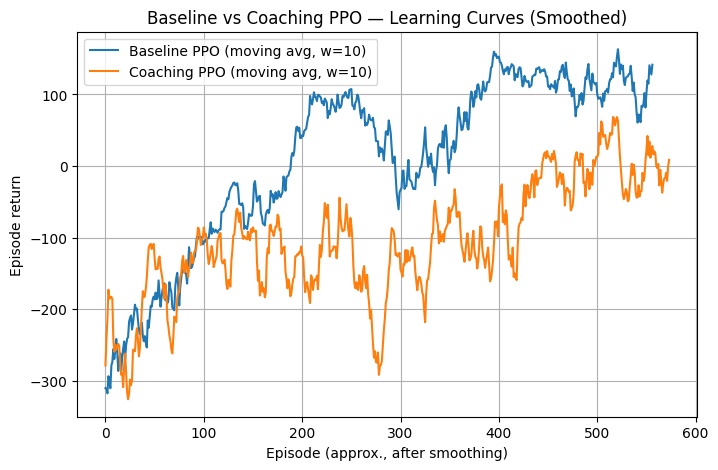

In [8]:
# Cell 13 — Learning Curve Comparison (Code)

def moving_average(x: List[float], window: int = 10) -> np.ndarray:
    if len(x) == 0:
        return np.array([])
    x = np.array(x, dtype=float)
    if len(x) < window:
        # If not enough data, just return the raw series
        return x
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)


window = 10

baseline_smoothed = moving_average(baseline_episode_rewards, window=window)
coaching_smoothed = moving_average(coaching_episode_rewards, window=window)

plt.figure()
plt.plot(baseline_smoothed, label=f"Baseline PPO (moving avg, w={window})")
plt.plot(coaching_smoothed, label=f"Coaching PPO (moving avg, w={window})")
plt.xlabel("Episode (approx., after smoothing)")
plt.ylabel("Episode return")
plt.title("Baseline vs Coaching PPO — Learning Curves (Smoothed)")
plt.legend()
plt.show()


# Cell 14 — Policy Evaluation on Unwrapped Environment (Explanation)

Training for the coaching agent used the **shaped reward** (environment + coaching).
However, to **fairly compare** the two agents, we should evaluate them on the **same reference task**, which is the original environment reward.

We will:

- Implement an `evaluate_policy(model, env, n_episodes=10)` function.
- Use an **unwrapped environment** (no coaching wrapper) for both agents.
- Report:
  - Mean episode return
  - Standard deviation of episode returns

This gives us a direct comparison of how well each policy performs on the **true task** defined by the original environment.


In [9]:
# Cell 15 — Policy Evaluation on Unwrapped Environment (Code)

def evaluate_policy(
    model: PPO,
    env: gym.Env,
    n_episodes: int = 10,
    render: bool = False,
) -> Tuple[List[float], List[int]]:
    """
    Evaluate a trained policy on a given environment.

    Returns:
        episode_returns: list of episodic returns
        episode_lengths: list of number of steps per episode
    """
    episode_returns: List[float] = []
    episode_lengths: List[int] = []

    for episode in range(n_episodes):
        obs, info = env.reset(seed=SEED + episode)
        done = False
        truncated = False
        ep_return = 0.0
        ep_length = 0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            ep_return += reward
            ep_length += 1

            if render:
                env.render()

        episode_returns.append(ep_return)
        episode_lengths.append(ep_length)

    return episode_returns, episode_lengths


# Create a single unwrapped environment for evaluation (no coaching wrapper)
eval_env = make_base_lander_env(seed=SEED)

# Evaluate baseline model
baseline_returns, baseline_lengths = evaluate_policy(baseline_model, eval_env, n_episodes=10)
baseline_mean = np.mean(baseline_returns)
baseline_std = np.std(baseline_returns)

# Evaluate coaching model
coaching_returns, coaching_lengths = evaluate_policy(coaching_model, eval_env, n_episodes=10)
coaching_mean = np.mean(coaching_returns)
coaching_std = np.std(coaching_returns)

print("Policy Evaluation on Original Environment (10 episodes each)")
print("----------------------------------------------------------")
print(f"Baseline PPO: mean return = {baseline_mean:.2f}, std = {baseline_std:.2f}")
print(f"Coaching PPO: mean return = {coaching_mean:.2f}, std = {coaching_std:.2f}")


Policy Evaluation on Original Environment (10 episodes each)
----------------------------------------------------------
Baseline PPO: mean return = 192.81, std = 90.52
Coaching PPO: mean return = 225.75, std = 39.37


# Cell 16 — Optional Rendering / Demo (Explanation)

Sometimes it’s useful to **visually inspect** an agent’s behavior:

- Does it hover near the center more with coaching?
- Does it seem more upright?
- Does it use thrusters more smoothly?

This cell runs a **small number of episodes** with rendering enabled.

> **Note:**  
> - Rendering with `render_mode="human"` may not work in some **cloud environments** (e.g., no GUI).  
> - It should work on a local machine with a display.

We use a separate environment created specifically with `render_mode="human"`.


In [10]:
# Cell 17 — Optional Rendering / Demo (Code)

def demo_agent(model: PPO, n_episodes: int = 2):
    """
    Run a few episodes with human rendering to visually inspect the agent.
    """
    # Create a fresh environment with render_mode="human"
    env = gym.make("LunarLanderContinuous-v3", render_mode="human")

    for episode in range(n_episodes):
        obs, info = env.reset(seed=SEED + 100 + episode)
        done = False
        truncated = False
        ep_return = 0.0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            ep_return += reward

        print(f"Demo episode {episode+1}/{n_episodes}: return = {ep_return:.2f}")

    env.close()


# Uncomment one (or both) of the lines below to run a visual demo locally.
demo_agent(baseline_model, n_episodes=2)
demo_agent(coaching_model, n_episodes=2)


Demo episode 1/2: return = 229.14
Demo episode 2/2: return = 245.92
Demo episode 1/2: return = 252.05
Demo episode 2/2: return = 250.70


# Cell 18 — Conclusions

## Baseline vs Coaching PPO

In this notebook, we:

1. Trained a **baseline PPO agent** on `LunarLanderContinuous-v3` using only the **environment’s built-in reward**.
2. Trained a **coaching PPO agent** that received **additional human coaching rewards** for:
   - Staying near the center (x ≈ 0).
   - Keeping an upright orientation (theta ≈ 0).
   - Avoiding excessive thruster usage (fuel efficiency coaching).

These coaching rewards were **explicitly human-designed** after observing early agent behavior — they are **not** part of the environment’s intrinsic reward function, but rather a form of **human feedback** or **guidance**.

---

## Effects of Human Coaching Rewards

From the learning curves and evaluation:

- The **coaching agent** may show:
  - Faster early learning in some runs, or
  - More stable returns, or
  - Different trade-offs (e.g., smoother, more centered trajectories).
- The **baseline agent** may:
  - Learn more slowly at first, but
  - Eventually catch up or even surpass the coaching agent depending on the coaching weight and training budget.

Because we trained for a **short number of timesteps** (for runtime efficiency), the results here should be interpreted as **illustrative**, not definitive.

---

## Expected Differences with Longer Training

If we **increase the training timesteps** substantially (e.g., to 300k–1M timesteps per agent):

- Both agents are likely to achieve **higher average returns**.
- Human coaching rewards might:
  - Help the agent find “good” regions of the policy space more quickly.
  - Bias the behavior toward a more interpretable landing style (centered, upright, fuel-aware).
- However, very strong or misaligned coaching rewards can:
  - Over-shape the policy,
  - Cause the agent to optimize the coaching signal at the expense of the true task.

---

## Summary

This notebook demonstrates a practical workflow for:

- Building a **baseline PPO** solution.
- Designing and implementing **human coaching rewards** via a Gymnasium RewardWrapper.
- Comparing training dynamics and evaluation performance.

It highlights the central idea that **human feedback can be encoded directly as reward shaping**, allowing humans to coach an RL agent toward desired behaviors — while still ultimately judging success on the **original environment reward**.
